In [1]:

import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
EXCHANGE_NAME = "kraken"   # change here only

exchange = getattr(ccxt, EXCHANGE_NAME)({
    "enableRateLimit": True
})

exchange.load_markets()
print(f"Connected to {EXCHANGE_NAME}")


Connected to kraken


In [3]:
symbol = "SOL/USD"   # Kraken format
timeframe = "15m"
limit = 300


ohlcv = exchange.fetch_ohlcv(
    symbol=symbol,
    timeframe=timeframe,
    limit=limit
)

df = pd.DataFrame(
    ohlcv,
    columns=["timestamp", "open", "high", "low", "close", "volume"]
)

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
df.tail()



,timestamp,open,high,low,close,volume
295,2026-03-11 21:30:00,87.21,87.51,87.21,87.39,593.429857
296,2026-03-11 21:45:00,87.41,87.63,87.41,87.54,433.010794
297,2026-03-11 22:00:00,87.56,87.91,87.39,87.77,843.934255
298,2026-03-11 22:15:00,87.78,87.78,87.18,87.19,1495.531603
299,2026-03-11 22:30:00,87.18,87.21,86.95,87.01,3944.284686


In [4]:
window = 20

df["return"] = df["close"].pct_change()
df["rolling_mean"] = df["close"].rolling(window).mean()
df["rolling_std"] = df["close"].rolling(window).std()

df.tail()


,timestamp,open,high,low,close,volume,return,rolling_mean,rolling_std
295,2026-03-11 21:30:00,87.21,87.51,87.21,87.39,593.429857,0.002179,87.2870,0.334650
296,2026-03-11 21:45:00,87.41,87.63,87.41,87.54,433.010794,0.001716,87.3425,0.271038
297,2026-03-11 22:00:00,87.56,87.91,87.39,87.77,843.934255,0.002627,87.4000,0.228312
298,2026-03-11 22:15:00,87.78,87.78,87.18,87.19,1495.531603,-0.006608,87.3760,0.223616
299,2026-03-11 22:30:00,87.18,87.21,86.95,87.01,3944.284686,-0.002064,87.3610,0.237883


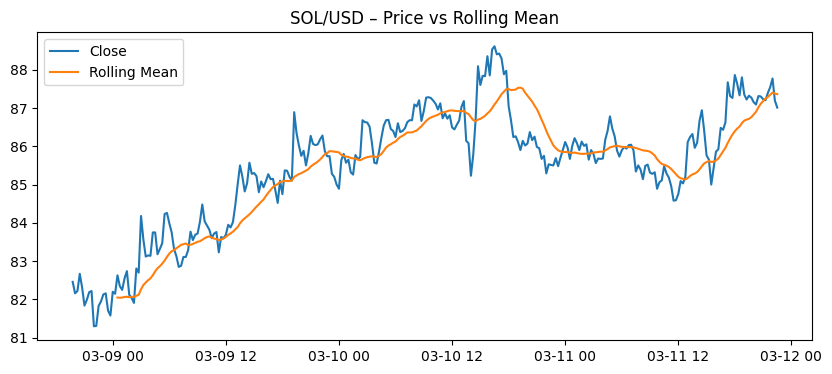

In [5]:
plt.figure(figsize=(10,4))
plt.plot(df["timestamp"], df["close"], label="Close")
plt.plot(df["timestamp"], df["rolling_mean"], label="Rolling Mean")
plt.legend()
plt.title(f"{symbol} – Price vs Rolling Mean")
plt.show()


---
## Strategy 1: Buy when price greater than rolling mean- sell on the opposite


In [6]:
def generate_signal(row):
    if row["close"] > row["rolling_mean"]:
        return 1   # BUY
    elif row["close"] < row["rolling_mean"]:
        return -1  # SELL
    return 0
#remove the nan values from the first few rows where rolling mean is not available
df["signal"] = df.apply(generate_signal, axis=1)
df = df.dropna(subset=["rolling_mean"])
df.head()


,timestamp,open,high,low,close,volume,return,rolling_mean,rolling_std,signal
19,2026-03-09 00:30:00,82.16,83.29,82.16,82.63,3866.117199,0.005843,82.0505,0.373440,1
20,2026-03-09 00:45:00,82.65,82.72,82.27,82.35,971.137950,-0.003389,82.0450,0.367860,1
21,2026-03-09 01:00:00,82.36,82.37,81.87,82.25,1502.780745,-0.001214,82.0495,0.369886,1
22,2026-03-09 01:15:00,82.25,82.87,82.20,82.55,6079.867520,0.003647,82.0660,0.384946,1
23,2026-03-09 01:30:00,82.55,82.80,82.25,82.74,3840.047296,0.002302,82.0695,0.390997,1


---
## calculating position size

In [7]:
initial_cash = 10_000

default_params_hw = {
    "target_pct": 0.018891423949377727,
    "stop_loss_pct": 0.01592197966910247,
    "rolling_window": 46,
    "risk_per_trade": 0.01835074768931478,
    "max_position": 0.4833420939920498,
    "entry_threshold": 0.001074370915760364,
    "exit_threshold": 0.0029794619459360345,
}

if "best_params_hw" in globals() and isinstance(best_params_hw, dict):
    # Merge with defaults so missing keys still get safe values.
    active_params_hw = default_params_hw.copy()
    active_params_hw.update({k: best_params_hw[k] for k in default_params_hw if k in best_params_hw})
    params_source = "optuna best_params_hw"
else:
    active_params_hw = default_params_hw.copy()
    params_source = "default params"

best_params_hw = active_params_hw.copy()

risk_per_trade = best_params_hw["risk_per_trade"]
max_position = best_params_hw["max_position"]
stop_loss_pct = best_params_hw["stop_loss_pct"]
target_pct = best_params_hw["target_pct"]

def position_size(cash, entry_price, stop_loss_pct=stop_loss_pct):
    risk_amount = cash * risk_per_trade
    stop_loss_price = entry_price * (1 - stop_loss_pct)
    stop_distance = entry_price - stop_loss_price
    if stop_distance <= 0:
        return 0
    return risk_amount / stop_distance

print(f"Using {params_source}:", best_params_hw)


Using default params: {'target_pct': 0.018891423949377727, 'stop_loss_pct': 0.01592197966910247, 'rolling_window': 46, 'risk_per_trade': 0.01835074768931478, 'max_position': 0.4833420939920498, 'entry_threshold': 0.001074370915760364, 'exit_threshold': 0.0029794619459360345}


---
## execution simulation

In [8]:
# ------------------------------------------------------------
# 1) Build a per-bar "decision log" (BUY / SELL / HOLD)
# ------------------------------------------------------------
df = df.copy()
df["signal"] = df["signal"].fillna(0).astype(int)

# decisions are only meaningful when rolling_mean exists
df["decision"] = np.where(df["rolling_mean"].isna(), "NA",
                   np.where(df["signal"] == 1, "BUY",
                   np.where(df["signal"] == -1, "SELL", "HOLD")))

In [9]:



# ------------------------------------------------------------
# 2) Build a TRADE LEDGER (fills) by walking decisions
# ------------------------------------------------------------
cash = initial_cash
position = 0.0
trades = []   # each element: dict

# equity tracking
equity_curve = []   # (timestamp, equity)

entry_price = None  # ...add this (track entry for stop-loss / target)

# target_pct is taken from the selected params (best_params_hw or defaults).

slip_pct = 0.0005  # 5 bps slippage

avg_entry = None  # changed this... weighted average entry price



for _, row in df.iterrows():
    if np.isnan(row["rolling_mean"]):
        continue

    ts = row["timestamp"]
    price = float(row["close"])
    sig = int(row["signal"])

    equity_curve.append((ts, cash + position * price))

    # compute size exactly like your strategy
    size = float(position_size(cash, price))

    # apply same max_position cap (value cap on total position)
    equity_now = cash + position * price
    max_position_value = max_position * equity_now

    desired_position_value = (position + size) * price
    if abs(desired_position_value) > max_position_value:
        target_position_value = np.sign(desired_position_value) * max_position_value
        target_position_units = target_position_value / price
        size = target_position_units - position

    # ---- stop-loss check ----
    stop_hit = False
    target_hit = False
    if position > 0 and avg_entry is not None:   # changed this...
        stop_price = avg_entry * (1 - stop_loss_pct)    # changed this...
        target_price = avg_entry * (1 + target_pct)     # changed this...
        if price <= stop_price:
            stop_hit = True
        elif price >= target_price:
            target_hit = True


    if sig == 1 and size > 0:
        fill = price * (1 + slip_pct)
        max_affordable_qty = cash / (fill * (1 + 0.001))  # changed this...
        size = min(size, max_affordable_qty)  # changed this...
        if size <= 0:
            continue
        notional = fill * size
        fee = 0.001 * notional

        cash -= (notional + fee)
        old_pos = position                     # changed this...
        position += size

        if old_pos == 0:                       # changed this...
            avg_entry = fill                   # changed this...
        else:
            avg_entry = (avg_entry * old_pos + fill * size) / (old_pos + size)  # changed this...


        trades.append({
            "timestamp": ts,
            "side": "BUY",
            "fill_price": fill,
            "qty": size,
            "notional": notional,
            "fee": fee,
            "cash_after": cash,
            "position_after": position
        })

    elif (sig == -1 or stop_hit or target_hit) and position > 0:
        fill = price * (1 - slip_pct)
        qty = position
        notional = fill * qty
        fee = 0.001 * notional
        cash += (notional - fee)

        position = 0.0
        avg_entry = None  # changed this...


        trades.append({
            "timestamp": ts,
            "side": "SELL",
            "reason": "STOP" if stop_hit else ("TARGET" if target_hit else "SIGNAL"),  # ...add this
            "fill_price": fill,
            "qty": qty,
            "notional": notional,
            "fee": fee,
            "cash_after": cash,
            "position_after": position
        })


In [10]:

# ------------------------------------------------------------
# 3) Trades DataFrame + Round-trip P&L DataFrame (BUY...BUY -> SELL)
# ------------------------------------------------------------
trades_df = pd.DataFrame(trades).sort_values("timestamp").reset_index(drop=True)

roundtrips = []
open_cost = 0.0
open_qty = 0.0
entry_time = None

for _, t in trades_df.iterrows():
    if t["side"] == "BUY":
        if open_qty == 0:
            entry_time = t["timestamp"]
        open_cost += (t["notional"] + t["fee"])     # cash outflow incl fee
        open_qty  += t["qty"]

    else:  # SELL closes full position in your logic
        proceeds = t["notional"] - t["fee"]          # cash inflow after fee
        pnl = proceeds - open_cost

        roundtrips.append({
            "entry_time": entry_time,
            "exit_time": t["timestamp"],
            "qty": open_qty,
            "buy_cost_incl_fees": open_cost,
            "sell_proceeds_after_fee": proceeds,
            "realized_pnl": pnl,
            "exit_reason": t.get("reason", "SELL")
        })

        open_cost = 0.0
        open_qty = 0.0
        entry_time = None

roundtrip_df = pd.DataFrame(roundtrips)
roundtrip_df.tail(20)

,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason
6,2026-03-09 17:45:00,2026-03-09 18:00:00,56.490171,4814.526934,4780.363081,-34.163853,SIGNAL
7,2026-03-09 18:15:00,2026-03-09 19:00:00,56.135153,4799.445914,4769.938282,-29.507632,SIGNAL
8,2026-03-09 19:15:00,2026-03-09 22:45:00,55.392114,4819.854295,4742.198279,-77.656016,SIGNAL
9,2026-03-10 00:30:00,2026-03-10 00:45:00,55.233147,4746.114906,4719.213319,-26.901587,SIGNAL
10,2026-03-10 01:45:00,2026-03-10 03:45:00,55.100867,4733.092726,4707.911073,-25.181653,SIGNAL
11,2026-03-10 04:15:00,2026-03-10 11:00:00,54.901351,4720.903110,4754.454173,33.551063,SIGNAL
12,2026-03-10 13:00:00,2026-03-10 13:30:00,54.349611,4737.144084,4674.655323,-62.488761,SIGNAL
13,2026-03-10 14:30:00,2026-03-10 16:15:00,54.208111,4706.895315,4791.847876,84.952561,TARGET
14,2026-03-10 16:30:00,2026-03-10 18:00:00,53.693338,4764.794635,4666.996372,-97.798263,STOP
15,2026-03-10 23:45:00,2026-03-11 00:30:00,54.640679,4700.677130,4674.047716,-26.629414,SIGNAL


---
## Final portfolio value

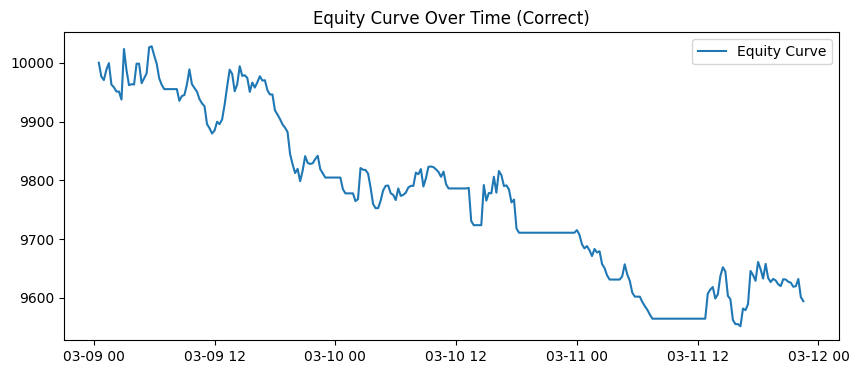

Final portfolio value (from curve): 9594.298672632216


In [11]:
eq = pd.DataFrame(equity_curve, columns=["timestamp", "equity"])

plt.figure(figsize=(10,4))
plt.plot(eq["timestamp"], eq["equity"], label="Equity Curve")
plt.legend()
plt.title("Equity Curve Over Time (Correct)")
plt.show()

print("Final portfolio value (from curve):", eq["equity"].iloc[-1])

---
### Actual trades executed

In [12]:
trades

[{'timestamp': Timestamp('2026-03-09 00:30:00'),
  'side': 'BUY',
  'fill_price': 82.67131499999999,
  'qty': 58.49474694324699,
  'notional': 4835.837650390458,
  'fee': 4.8358376503904585,
  'cash_after': 5159.3265119591515,
  'position_after': 58.49474694324699},
 {'timestamp': Timestamp('2026-03-09 00:45:00'),
  'side': 'BUY',
  'fill_price': 82.39117499999999,
  'qty': 0.06018985762984386,
  'notional': 4.95911309320555,
  'fee': 0.00495911309320555,
  'cash_after': 5154.362439752853,
  'position_after': 58.55493680087683},
 {'timestamp': Timestamp('2026-03-09 01:00:00'),
  'side': 'BUY',
  'fill_price': 82.291125,
  'qty': 0.036737900062902895,
  'notional': 3.0232031263138497,
  'fee': 0.00302320312631385,
  'cash_after': 5151.336213423413,
  'position_after': 58.591674700939734},
 {'timestamp': Timestamp('2026-03-09 01:45:00'),
  'side': 'BUY',
  'fill_price': 82.16106,
  'qty': 0.04789514439840303,
  'notional': 3.935115832625856,
  'fee': 0.003935115832625856,
  'cash_after':

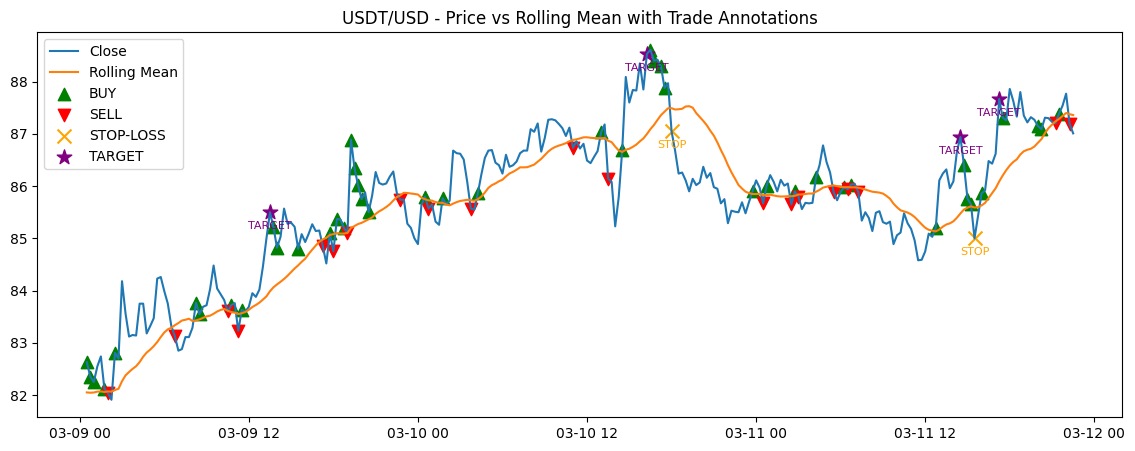

In [13]:
# ------------------------------------------------------------
# 4) Plot price + rolling mean + annotated BUY/SELL/STOP/TARGET
# ------------------------------------------------------------
plt.figure(figsize=(14,5))
plt.plot(df['timestamp'], df['close'], label='Close')
plt.plot(df['timestamp'], df['rolling_mean'], label='Rolling Mean')

trades_df_hw = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)
buy_pts = trades_df_hw[trades_df_hw['side'] == 'BUY'].merge(df[['timestamp','close']], on='timestamp', how='left')
sell_pts = trades_df_hw[trades_df_hw['side'] == 'SELL'].merge(df[['timestamp','close']], on='timestamp', how='left')

# split by reason
if 'reason' in sell_pts.columns:
    stop_pts = sell_pts[sell_pts['reason'] == 'STOP']
    target_pts = sell_pts[sell_pts['reason'] == 'TARGET']
    normal_sell_pts = sell_pts[~sell_pts['reason'].isin(['STOP','TARGET'])]
else:
    stop_pts = sell_pts.iloc[0:0]
    target_pts = sell_pts.iloc[0:0]
    normal_sell_pts = sell_pts

plt.scatter(buy_pts['timestamp'], buy_pts['close'], marker='^', s=80, color='green', label='BUY')
plt.scatter(normal_sell_pts['timestamp'], normal_sell_pts['close'], marker='v', s=80, color='red', label='SELL')
plt.scatter(stop_pts['timestamp'], stop_pts['close'], marker='x', s=100, color='orange', label='STOP-LOSS')
plt.scatter(target_pts['timestamp'], target_pts['close'], marker='*', s=120, color='purple', label='TARGET')

# annotate only STOP/TARGET to reduce clutter
for _, r in stop_pts.iterrows():
    plt.annotate('STOP', (r['timestamp'], r['close']), xytext=(0, -12), textcoords='offset points', ha='center', fontsize=8, color='orange')
for _, r in target_pts.iterrows():
    plt.annotate('TARGET', (r['timestamp'], r['close']), xytext=(0, -12), textcoords='offset points', ha='center', fontsize=8, color='purple')

plt.title('USDT/USD - Price vs Rolling Mean with Trade Annotations')
plt.legend()
plt.show()


### Candlestick + Rolling Mean + interactive BUY/SELL annotations (Plotly)

In [14]:
import plotly.graph_objects as go

df2 = df.sort_values('timestamp')[-50:].copy()
df2['timestamp'] = pd.to_datetime(df2['timestamp'])

tr = trades_df.copy()
tr['timestamp'] = pd.to_datetime(tr['timestamp'])
tr = tr[tr['timestamp'].isin(df2['timestamp'])]

buy_pts = tr[tr['side'] == 'BUY'].merge(df2[['timestamp','close']], on='timestamp', how='left')
sell_pts = tr[tr['side'] == 'SELL'].merge(df2[['timestamp','close']], on='timestamp', how='left')

if 'reason' in sell_pts.columns:
    stop_pts = sell_pts[sell_pts['reason'] == 'STOP']
    target_pts = sell_pts[sell_pts['reason'] == 'TARGET']
    normal_sell_pts = sell_pts[~sell_pts['reason'].isin(['STOP','TARGET'])]
else:
    stop_pts = sell_pts.iloc[0:0]
    target_pts = sell_pts.iloc[0:0]
    normal_sell_pts = sell_pts

fig = go.Figure()
fig.add_trace(go.Candlestick(
    x=df2['timestamp'], open=df2['open'], high=df2['high'], low=df2['low'], close=df2['close'], name='OHLC'
))
fig.add_trace(go.Scatter(
    x=df2['timestamp'], y=df2['rolling_mean'], mode='lines', name='Rolling Mean'
))
fig.add_trace(go.Scatter(
    x=buy_pts['timestamp'], y=buy_pts['close'], mode='markers',
    name='BUY', marker=dict(symbol='triangle-up', size=10, color='green')
))
fig.add_trace(go.Scatter(
    x=normal_sell_pts['timestamp'], y=normal_sell_pts['close'], mode='markers',
    name='SELL', marker=dict(symbol='triangle-down', size=10, color='red')
))
fig.add_trace(go.Scatter(
    x=stop_pts['timestamp'], y=stop_pts['close'], mode='markers+text',
    name='STOP-LOSS', marker=dict(symbol='x', size=12, color='orange'),
    text=['STOP']*len(stop_pts), textposition='bottom center'
))
fig.add_trace(go.Scatter(
    x=target_pts['timestamp'], y=target_pts['close'], mode='markers+text',
    name='TARGET', marker=dict(symbol='star', size=12, color='purple'),
    text=['TARGET']*len(target_pts), textposition='bottom center'
))

fig.update_layout(
    title=f"{symbol} - Candlestick + Rolling Mean + Trades",
    xaxis_title='Time', yaxis_title='Price', xaxis_rangeslider_visible=False, hovermode='x unified', height=520
)
fig.show()


In [15]:
# ------------------------------------------------------------
# 5) Trade summary tables:
# ------------------------------------------------------------
# --- cumulative appreciation / drawdown % relative to initial cash ---
roundtrip_df["cum_equity"] = initial_cash + roundtrip_df["realized_pnl"].cumsum()
roundtrip_df["cum_return_pct"] = (
    (roundtrip_df["cum_equity"] - initial_cash) / initial_cash
) * 100
print("Round-trip P&L (each BUY... -> SELL):")
display(roundtrip_df.tail(20))

Round-trip P&L (each BUY... -> SELL):


,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason,cum_equity,cum_return_pct
6,2026-03-09 17:45:00,2026-03-09 18:00:00,56.490171,4814.526934,4780.363081,-34.163853,SIGNAL,9911.821858,-0.881781
7,2026-03-09 18:15:00,2026-03-09 19:00:00,56.135153,4799.445914,4769.938282,-29.507632,SIGNAL,9882.314226,-1.176858
8,2026-03-09 19:15:00,2026-03-09 22:45:00,55.392114,4819.854295,4742.198279,-77.656016,SIGNAL,9804.658210,-1.953418
9,2026-03-10 00:30:00,2026-03-10 00:45:00,55.233147,4746.114906,4719.213319,-26.901587,SIGNAL,9777.756623,-2.222434
10,2026-03-10 01:45:00,2026-03-10 03:45:00,55.100867,4733.092726,4707.911073,-25.181653,SIGNAL,9752.574970,-2.474250
11,2026-03-10 04:15:00,2026-03-10 11:00:00,54.901351,4720.903110,4754.454173,33.551063,SIGNAL,9786.126033,-2.138740
12,2026-03-10 13:00:00,2026-03-10 13:30:00,54.349611,4737.144084,4674.655323,-62.488761,SIGNAL,9723.637272,-2.763627
13,2026-03-10 14:30:00,2026-03-10 16:15:00,54.208111,4706.895315,4791.847876,84.952561,TARGET,9808.589834,-1.914102
14,2026-03-10 16:30:00,2026-03-10 18:00:00,53.693338,4764.794635,4666.996372,-97.798263,STOP,9710.791571,-2.892084
15,2026-03-10 23:45:00,2026-03-11 00:30:00,54.640679,4700.677130,4674.047716,-26.629414,SIGNAL,9684.162156,-3.158378


<Axes: >

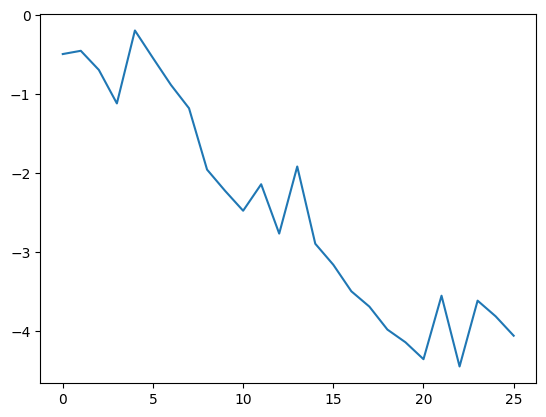

In [16]:
roundtrip_df['cum_return_pct'].plot()

In [17]:
# # extract roundtrip_df for exit_reason is target
# roundtrip_df[roundtrip_df["exit_reason"] == "TARGET"]


In [18]:
roundtrip_df["exit_reason"].value_counts()

exit_reason
SIGNAL    20
TARGET     4
STOP       2
Name: count, dtype: int64

## Find the best parameters using optuna

In [19]:

import optuna
import numpy as np

def run_backtest(params, df):
    # unpack params
    target_pct = 0.01906075805744769
    slip_pct = 0.0005  # 5 bps slippage
    stop_loss_pct = 0.0227435761302825
    rolling_window = params["rolling_window"]
    risk_per_trade = 0.028910767897057446
    max_position = 0.42914636308932985

    # --- rebuild rolling mean + signals ---
    df = df.copy()
    df["rolling_mean"] = df["close"].rolling(rolling_window).mean()
    df["signal"] = np.where(df["close"] > df["rolling_mean"], 1,
                     np.where(df["close"] < df["rolling_mean"], -1, 0))
    df = df.dropna(subset=["rolling_mean"])

    # --- trading loop (same as your ledger logic) ---
    cash = initial_cash
    position = 0.0
    avg_entry = None

    for _, row in df.iterrows():
        price = float(row["close"])
        sig = int(row["signal"])

        # position size
        risk_amount = cash * risk_per_trade
        stop_price = price * (1 - stop_loss_pct)
        stop_dist = price - stop_price
        if stop_dist <= 0:
            continue
        size = risk_amount / stop_dist

        # cap max position
        equity_now = cash + position * price
        max_position_value = max_position * equity_now
        desired_value = (position + size) * price
        if abs(desired_value) > max_position_value:
            size = (np.sign(desired_value) * max_position_value / price) - position

        # stop/target logic
        stop_hit = False
        target_hit = False
        bar_low = float(row["low"])  # changed this...
        bar_high = float(row["high"])  # changed this...
        if position > 0 and avg_entry is not None:
            stop_price = avg_entry * (1 - stop_loss_pct)
            target_price = avg_entry * (1 + target_pct)
            if bar_low <= stop_price:  # changed this...
                stop_hit = True
            elif bar_high >= target_price:  # changed this...
                target_hit = True

        if sig == 1 and size > 0:
            fill = price * (1 + slip_pct)
            notional = fill * size
            fee = 0.001 * notional
            cash -= (notional + fee)
            old_pos = position
            position += size
            if old_pos == 0:
                avg_entry = fill
            else:
                avg_entry = (avg_entry * old_pos + fill * size) / (old_pos + size)

        elif (sig == -1 or stop_hit or target_hit) and position > 0:
            fill = price * (1 - slip_pct)
            qty = position
            notional = fill * qty
            fee = 0.001 * notional
            cash += (notional - fee)
            position = 0.0
            avg_entry = None

    final_equity = cash + position * df["close"].iloc[-1]
    return final_equity

def objective(trial):
    params = {
        "target_pct": trial.suggest_float("target_pct", 0.002, 0.02),
        "stop_loss_pct": trial.suggest_float("stop_loss_pct", 0.002, 0.02),
        "rolling_window": trial.suggest_int("rolling_window", 10, 200),
        "risk_per_trade": trial.suggest_float("risk_per_trade", 0.001, 0.02),
        "max_position": trial.suggest_float("max_position", 0.05, 0.5)
    }
    return run_backtest(params, df)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best_params_hw = study.best_params.copy()
best_equity_hw = study.best_value

print("Best params:", best_params_hw)
print("Best equity:", best_equity_hw)


[I 2026-03-11 17:41:59,080] A new study created in memory with name: no-name-267fd389-f496-4527-a8e2-237e3614b265
[I 2026-03-11 17:41:59,085] Trial 0 finished with value: 9809.588112295136 and parameters: {'target_pct': 0.008195789400193878, 'stop_loss_pct': 0.017741784773836283, 'rolling_window': 111, 'risk_per_trade': 0.017742792271908055, 'max_position': 0.08235169361288983}. Best is trial 0 with value: 9809.588112295136.
[I 2026-03-11 17:41:59,090] Trial 1 finished with value: 9859.286916597302 and parameters: {'target_pct': 0.016707771981716184, 'stop_loss_pct': 0.010682451444004535, 'rolling_window': 37, 'risk_per_trade': 0.004384682865836396, 'max_position': 0.2335908439839367}. Best is trial 1 with value: 9859.286916597302.
[I 2026-03-11 17:41:59,096] Trial 2 finished with value: 9937.735745758611 and parameters: {'target_pct': 0.017412632995812395, 'stop_loss_pct': 0.005888498455004066, 'rolling_window': 64, 'risk_per_trade': 0.0032059796467244525, 'max_position': 0.4339400569

Best params: {'target_pct': 0.0041022753469301095, 'stop_loss_pct': 0.01963766152750088, 'rolling_window': 69, 'risk_per_trade': 0.0021212026092452554, 'max_position': 0.46415157930688294}
Best equity: 10027.241541403351


Best params: {'target_pct': 0.014702770869452764, 'stop_loss_pct': 0.017121172269991717, 'rolling_window': 22, 'risk_per_trade': 0.007700572798621764, 'max_position': 0.3405384934518047}
Best equity: 10077.089534061412


## Forecasting future price

In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# make sure df is time sorted
df = df.sort_values("timestamp").copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])

y = df["close"].astype(float).values

# rolling next-bar forecast (stored at row t, targets close[t+1])
hw_preds = [np.nan]  # first row has no forecast

for t in range(1, len(y)):
    history = y[:t]
    try:
        model = ExponentialSmoothing(
            history, trend="add", seasonal=None
        ).fit(optimized=True)
        hw_preds.append(model.forecast(2)[1])
    except Exception:
        hw_preds.append(np.nan)

df["hw_next_close"] = hw_preds


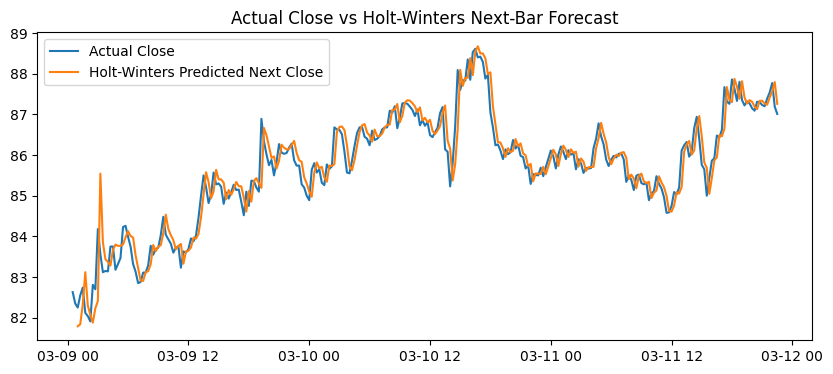

In [21]:
# plot df actual vs predicted close
plt.figure(figsize=(10,4))
plt.plot(df["timestamp"], df["close"], label="Actual Close")
plt.plot(df["timestamp"], df["hw_next_close"], label="Holt-Winters Predicted Next Close")
plt.legend()
plt.title("Actual Close vs Holt-Winters Next-Bar Forecast")
plt.show()

In [22]:
# check model performance using MAPE,RMSE
actual = df["close"].shift(-1)       # actual next-bar close (aligned to prediction at row t)
pred   = df["hw_next_close"]         # predicted next-bar close

err_df = pd.DataFrame({"actual": actual, "pred": pred}).dropna()

mape = (np.abs((err_df["actual"] - err_df["pred"]) / err_df["actual"]).mean()) * 100
rmse = np.sqrt(((err_df["actual"] - err_df["pred"]) ** 2).mean())

print(f"Holt-Winters Forecast MAPE: {mape:.4f}%")
print(f"Holt-Winters Forecast RMSE: {rmse:.6f}")


Holt-Winters Forecast MAPE: 0.4606%
Holt-Winters Forecast RMSE: 0.530967


In [23]:
# ---- Strategy signals based on Holt-Winters next-bar forecast ----
df = df.copy()
df['signal'] = 0
# Backfill missing keys if best_params_hw came from older tuning
best_params_hw = (best_params_hw if isinstance(best_params_hw, dict) else {})
rolling_window = int(best_params_hw["rolling_window"])
df['rolling_mean'] = df['close'].rolling(rolling_window).mean()
df['f_ret'] = (df["hw_next_close"] - df['close']) / df['close']

w = rolling_window
df['ma_f1'] = df['rolling_mean'] + (df['hw_next_close'] - df['close'].shift(w-1)) / w


entry_threshold = best_params_hw.get("entry_threshold", 0.001074370915760364)  #changed here
exit_threshold = best_params_hw.get("exit_threshold", 0.0029794619459360345)  #changed here

long_condition = (df['close'] > df['rolling_mean']) & (df['f_ret'] > entry_threshold)
short_condition = (df['hw_next_close'] < df['ma_f1']) & (df['f_ret'] < -exit_threshold)

df.loc[long_condition, 'signal'] = 1
df.loc[short_condition, 'signal'] = -1

# ---- Build trades + roundtrip_df (same structure as earlier) ----
cash = initial_cash
position = 0.0
trades = []
equity_curve = []

avg_entry = None
target_pct = best_params_hw["target_pct"]
stop_loss_pct = best_params_hw["stop_loss_pct"]
slip_pct = slip_pct

for _, row in df.iterrows():
    if np.isnan(row['rolling_mean']):
        continue

    ts = row['timestamp']
    price = float(row['close'])
    sig = int(row['signal'])
    bar_low = float(row['low'])
    bar_high = float(row['high'])

    equity_curve.append((ts, cash + position * price))

    # position sizing (same as main strategy)
    risk_amount = cash * risk_per_trade
    stop_price_tmp = price * (1 - stop_loss_pct)
    stop_dist = price - stop_price_tmp
    if stop_dist <= 0:
        continue
    size = risk_amount / stop_dist

    equity_now = cash + position * price
    max_position_value = max_position * equity_now
    desired_value = (position + size) * price
    if abs(desired_value) > max_position_value:
        size = (np.sign(desired_value) * max_position_value / price) - position

    # stop/target checks
    stop_hit = False
    target_hit = False
    if position > 0 and avg_entry is not None:
        stop_price = avg_entry * (1 - stop_loss_pct)
        target_price = avg_entry * (1 + target_pct)
        if bar_low <= stop_price:
            stop_hit = True
        elif bar_high >= target_price:
            target_hit = True

    # BUY
    if sig == 1 and size > 0:
        fill = price * (1 + slip_pct)
        max_affordable_qty = cash / (fill * (1 + 0.001))
        size = min(size, max_affordable_qty)
        if size <= 0:
            continue
        notional = fill * size
        fee = 0.001 * notional
        cash -= (notional + fee)
        old_pos = position
        position += size
        if old_pos == 0:
            avg_entry = fill
        else:
            avg_entry = (avg_entry * old_pos + fill * size) / (old_pos + size)
        trades.append({
            'timestamp': ts, 'side': 'BUY', 'fill_price': fill, 'qty': size,
            'notional': notional, 'fee': fee, 'cash_after': cash, 'position_after': position
        })

    # SELL (signal/stop/target)
    elif (sig == -1 or stop_hit or target_hit) and position > 0:
        fill = price * (1 - slip_pct)
        qty = position
        notional = fill * qty
        fee = 0.001 * notional
        cash += (notional - fee)
        position = 0.0
        avg_entry = None
        trades.append({
            'timestamp': ts, 'side': 'SELL',
            'reason': 'STOP' if stop_hit else ('TARGET' if target_hit else 'SIGNAL'),
            'fill_price': fill, 'qty': qty, 'notional': notional, 'fee': fee,
            'cash_after': cash, 'position_after': position
        })

    equity_curve.append((ts, cash + position * price))

if trades:
    trades_df_hw = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)  #changed here
else:
    trades_df_hw = pd.DataFrame(columns=['timestamp','side','reason','fill_price','qty','notional','fee','cash_after','position_after'])  #changed here

# Round-trip P&L
roundtrips = []
open_cost = 0.0
open_qty = 0.0
entry_time = None

for _, t in trades_df_hw.iterrows():
    if t['side'] == 'BUY':
        if open_qty == 0:
            entry_time = t['timestamp']
        open_cost += (t['notional'] + t['fee'])
        open_qty  += t['qty']
    else:
        proceeds = t['notional'] - t['fee']
        pnl = proceeds - open_cost
        roundtrips.append({
            'entry_time': entry_time,
            'exit_time': t['timestamp'],
            'qty': open_qty,
            'buy_cost_incl_fees': open_cost,
            'sell_proceeds_after_fee': proceeds,
            'realized_pnl': pnl,
            'exit_reason': t.get('reason', 'SELL')
        })
        open_cost = 0.0
        open_qty = 0.0
        entry_time = None

roundtrip_df_hw = pd.DataFrame(roundtrips)
if roundtrip_df_hw.empty:
    roundtrip_df_hw = pd.DataFrame(columns=['entry_time','exit_time','qty','buy_cost_incl_fees','sell_proceeds_after_fee','realized_pnl','exit_reason'])  #changed here
display(roundtrip_df_hw.tail(20))


,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason
0,2026-03-09 17:30:00,2026-03-09 17:45:00,57.186712,4840.673488,4859.291783,18.618295,TARGET
1,2026-03-09 18:00:00,2026-03-09 18:15:00,57.137698,4849.685997,4870.530989,20.844993,TARGET
2,2026-03-09 18:45:00,2026-03-09 19:15:00,56.954169,4859.776377,4941.327106,81.550729,TARGET
3,2026-03-09 19:30:00,2026-03-10 02:30:00,57.115168,4938.314351,4943.319094,5.004743,TARGET
4,2026-03-10 03:15:00,2026-03-10 05:15:00,56.861299,4926.236226,4921.914540,-4.321687,TARGET
5,2026-03-10 05:30:00,2026-03-10 07:15:00,56.620479,4902.178792,4897.676995,-4.501797,TARGET
6,2026-03-10 08:45:00,2026-03-10 09:15:00,56.428183,4897.403895,4917.103273,19.699378,TARGET
7,2026-03-10 10:00:00,2026-03-10 14:00:00,56.404781,4925.200079,4800.170845,-125.029234,STOP
8,2026-03-10 15:00:00,2026-03-10 15:30:00,55.241507,4846.417151,4844.586177,-1.830973,TARGET
9,2026-03-10 16:00:00,2026-03-10 16:15:00,55.074229,4845.530836,4868.410342,22.879506,TARGET


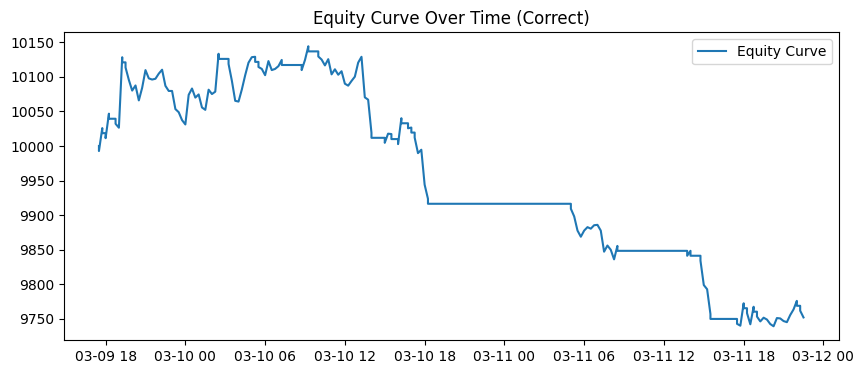

Final portfolio value (from curve): 9752.056124179795


In [24]:
eq = pd.DataFrame(equity_curve, columns=["timestamp", "equity"])

plt.figure(figsize=(10,4))
plt.plot(eq["timestamp"], eq["equity"], label="Equity Curve")
plt.legend()
plt.title("Equity Curve Over Time (Correct)")
plt.show()

print("Final portfolio value (from curve):", eq["equity"].iloc[-1])

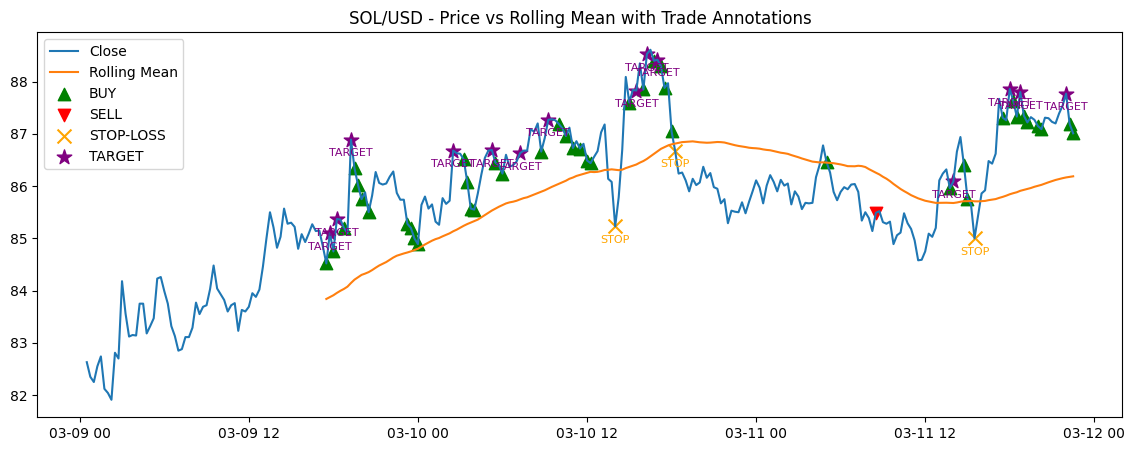

In [25]:
# ------------------------------------------------------------
# 4) Plot price + rolling mean + annotated BUY/SELL/STOP/TARGET
# ------------------------------------------------------------
plt.figure(figsize=(14,5))
plt.plot(df['timestamp'], df['close'], label='Close')
plt.plot(df['timestamp'], df['rolling_mean'], label='Rolling Mean')

trades_df_hw = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)
buy_pts = trades_df_hw[trades_df_hw['side'] == 'BUY'].merge(df[['timestamp','close']], on='timestamp', how='left')
sell_pts = trades_df_hw[trades_df_hw['side'] == 'SELL'].merge(df[['timestamp','close']], on='timestamp', how='left')

# split by reason
if 'reason' in sell_pts.columns:
    stop_pts = sell_pts[sell_pts['reason'] == 'STOP']
    target_pts = sell_pts[sell_pts['reason'] == 'TARGET']
    normal_sell_pts = sell_pts[~sell_pts['reason'].isin(['STOP','TARGET'])]
else:
    stop_pts = sell_pts.iloc[0:0]
    target_pts = sell_pts.iloc[0:0]
    normal_sell_pts = sell_pts

plt.scatter(buy_pts['timestamp'], buy_pts['close'], marker='^', s=80, color='green', label='BUY')
plt.scatter(normal_sell_pts['timestamp'], normal_sell_pts['close'], marker='v', s=80, color='red', label='SELL')
plt.scatter(stop_pts['timestamp'], stop_pts['close'], marker='x', s=100, color='orange', label='STOP-LOSS')
plt.scatter(target_pts['timestamp'], target_pts['close'], marker='*', s=120, color='purple', label='TARGET')

# annotate only STOP/TARGET to reduce clutter
for _, r in stop_pts.iterrows():
    plt.annotate('STOP', (r['timestamp'], r['close']), xytext=(0, -12), textcoords='offset points', ha='center', fontsize=8, color='orange')
for _, r in target_pts.iterrows():
    plt.annotate('TARGET', (r['timestamp'], r['close']), xytext=(0, -12), textcoords='offset points', ha='center', fontsize=8, color='purple')

plt.title('SOL/USD - Price vs Rolling Mean with Trade Annotations')
plt.legend()
plt.show()



In [26]:
#roundtrip_df

In [27]:
# ------------------------------------------------------------
# 5) Trade summary tables:
# ------------------------------------------------------------
# --- cumulative appreciation / drawdown % relative to initial cash ---
roundtrip_df_hw["cum_equity"] = initial_cash + roundtrip_df_hw["realized_pnl"].cumsum()
roundtrip_df_hw["cum_return_pct"] = (
    (roundtrip_df_hw["cum_equity"] - initial_cash) / initial_cash
) * 100
print("Round-trip P&L (each BUY... -> SELL):")
display(roundtrip_df_hw.tail(20))

Round-trip P&L (each BUY... -> SELL):


,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason,cum_equity,cum_return_pct
0,2026-03-09 17:30:00,2026-03-09 17:45:00,57.186712,4840.673488,4859.291783,18.618295,TARGET,10018.618295,0.186183
1,2026-03-09 18:00:00,2026-03-09 18:15:00,57.137698,4849.685997,4870.530989,20.844993,TARGET,10039.463287,0.394633
2,2026-03-09 18:45:00,2026-03-09 19:15:00,56.954169,4859.776377,4941.327106,81.550729,TARGET,10121.014017,1.210140
3,2026-03-09 19:30:00,2026-03-10 02:30:00,57.115168,4938.314351,4943.319094,5.004743,TARGET,10126.018760,1.260188
4,2026-03-10 03:15:00,2026-03-10 05:15:00,56.861299,4926.236226,4921.914540,-4.321687,TARGET,10121.697073,1.216971
5,2026-03-10 05:30:00,2026-03-10 07:15:00,56.620479,4902.178792,4897.676995,-4.501797,TARGET,10117.195277,1.171953
6,2026-03-10 08:45:00,2026-03-10 09:15:00,56.428183,4897.403895,4917.103273,19.699378,TARGET,10136.894655,1.368947
7,2026-03-10 10:00:00,2026-03-10 14:00:00,56.404781,4925.200079,4800.170845,-125.029234,STOP,10011.865421,0.118654
8,2026-03-10 15:00:00,2026-03-10 15:30:00,55.241507,4846.417151,4844.586177,-1.830973,TARGET,10010.034447,0.100344
9,2026-03-10 16:00:00,2026-03-10 16:15:00,55.074229,4845.530836,4868.410342,22.879506,TARGET,10032.913953,0.329140
